# EMPLOYEE SALARY PREDECTION

**PROBLEM STATEMENT:** Predict the salary of employee.

**Dataset:** Employee Salary Predection Dataset downloaded from keggle. (Path : https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

| Column | Description |
|:--------|-------------|
|work_year	|The year the salary was paid.
|experience_level	|The experience level in the job during the year with the following possible values: EN Entry-level / Junior MI Mid-level / Intermediate SE Senior-level / Expert EX Executive-level / Director
|employment_type	|The type of employement for the role: PT Part-time FT Full-time CT Contract FL Freelance
|job_title |The role worked in during the year.
 |salary	 |The total gross salary amount paid.
 |salary_currency	 |The currency of the salary paid as an ISO 4217 currency code.
 |salary_in_usd	 |The salary in USD (FX rate divided by avg. USD rate for the respective year via fxdata.foorilla.com).
 |employee_residence	 |Employee's primary country of residence in during the work year as an ISO 3166 country code.
 |remote_ratio	 |The overall amount of work done remotely, possible values are as follows: 0 No remote work (less than 20%) 50 Partially remote 100 Fully  |remote (more than 80%)
 |company_location	 |The country of the employer's main office or contracting branch as an ISO 3166 country code.
 |company_size	 |The average number of people that worked for the company during the year: S less than 50 employees (small) M 50 to 250 employees (medium) L more than 250 employees (large)

This project contains:
1. EDA
2. Cleaning & Preprocessing
3. Train 3 ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyperparameter tuning
7. Predict on unseen data

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [5]:
df = pd.read_csv('../datasets/ds_salaries.csv')
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## 3. Data Preperation

In [6]:
df = df.drop(columns=['Unnamed: 0','salary','salary_currency','employee_residence', 'company_location'], axis=1)
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_size
0,2020,MI,FT,Data Scientist,79833,0,L
1,2020,SE,FT,Machine Learning Scientist,260000,0,S
2,2020,SE,FT,Big Data Engineer,109024,50,M
3,2020,MI,FT,Product Data Analyst,20000,0,S
4,2020,SE,FT,Machine Learning Engineer,150000,50,L


## 4. EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         607 non-null    int64 
 1   experience_level  607 non-null    object
 2   employment_type   607 non-null    object
 3   job_title         607 non-null    object
 4   salary_in_usd     607 non-null    int64 
 5   remote_ratio      607 non-null    int64 
 6   company_size      607 non-null    object
dtypes: int64(3), object(4)
memory usage: 33.3+ KB


In [8]:
df.describe()

,work_year,salary_in_usd,remote_ratio
count,607.000000,607.000000,607.00000
mean,2021.405272,112297.869852,70.92257
std,0.692133,70957.259411,40.70913
min,2020.000000,2859.000000,0.00000
25%,2021.000000,62726.000000,50.00000
50%,2022.000000,101570.000000,100.00000
75%,2022.000000,150000.000000,100.00000
max,2022.000000,600000.000000,100.00000


In [9]:
df['work_year'] = df['work_year'].astype('object')
df['remote_ratio'] = df['remote_ratio'].astype('object')

In [10]:
df.describe(include='object')

,work_year,experience_level,employment_type,job_title,remote_ratio,company_size
count,607,607,607,607,607,607
unique,3,4,4,50,3,3
top,2022,SE,FT,Data Scientist,100,M
freq,318,280,588,143,381,326


In [11]:
df.isnull().sum()

work_year           0
experience_level    0
employment_type     0
job_title           0
salary_in_usd       0
remote_ratio        0
company_size        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(48)

In [13]:
df = df.drop_duplicates()
df.shape

(559, 7)

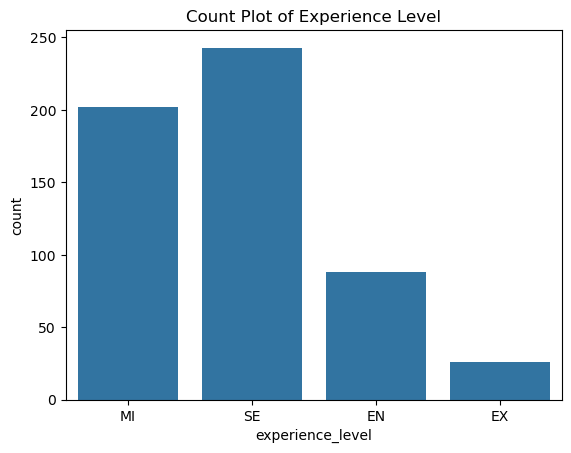

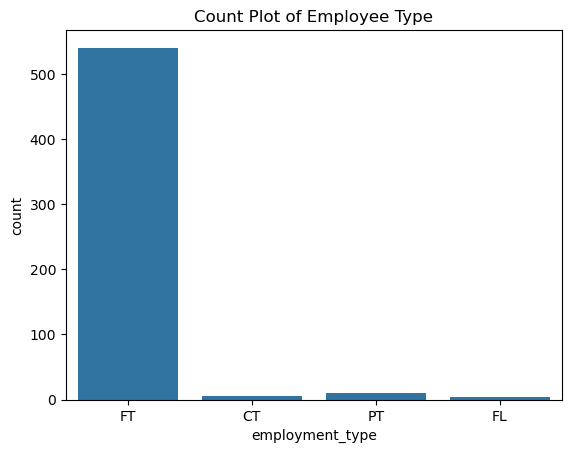

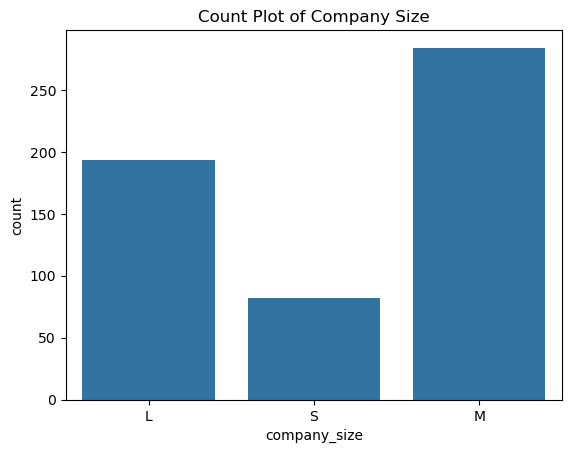

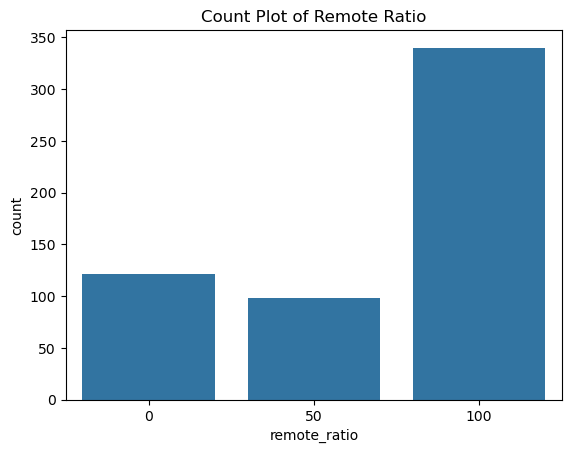

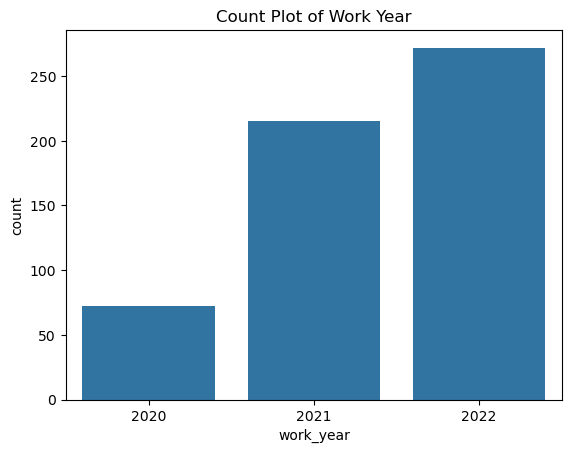

In [14]:
sns.countplot(x = df.experience_level)
plt.title("Count Plot of Experience Level")
plt.show()
sns.countplot(x = df.employment_type)
plt.title("Count Plot of Employee Type")
plt.show()
sns.countplot(x = df.company_size)
plt.title("Count Plot of Company Size")
plt.show()
sns.countplot(x = df.remote_ratio)
plt.title("Count Plot of Remote Ratio")
plt.show()
sns.countplot(x = df.work_year)
plt.title("Count Plot of Work Year")
plt.show()

In [15]:
(df.groupby('company_size')['salary_in_usd'].mean()).round(2)

company_size
L    118213.88
M    115974.76
S     77872.10
Name: salary_in_usd, dtype: float64

- Here we can see the Average Salary at Large Companies are comparatively higher.

In [16]:
(df.groupby('experience_level')['salary_in_usd'].mean()).round(2)


experience_level
EN     61643.32
EX    199392.04
MI     88632.28
SE    138374.88
Name: salary_in_usd, dtype: float64

- Here we can see the Average salary of an Expert is Much higher then others.

In [17]:
(df.groupby('employment_type')['salary_in_usd'].mean()).round(2)


employment_type
CT    184575.00
FL     48000.00
FT    112392.67
PT     33070.50
Name: salary_in_usd, dtype: float64

- Here we can see that the Average Salary of Contract Based Employee are much more then other employees.

In [18]:
(df.groupby('remote_ratio')['salary_in_usd'].mean()).round(2)

remote_ratio
0      105785.40
50      80721.90
100    121843.65
Name: salary_in_usd, dtype: float64

- Here we can see that Avg Salary of Totally Remote worker is more than others

In [19]:
(df.groupby('work_year')['salary_in_usd'].mean()).round(2)


work_year
2020     95813.00
2021     99430.41
2022    124490.98
Name: salary_in_usd, dtype: float64

- Here we can see that the employees of year 2022 has higher average Salary.

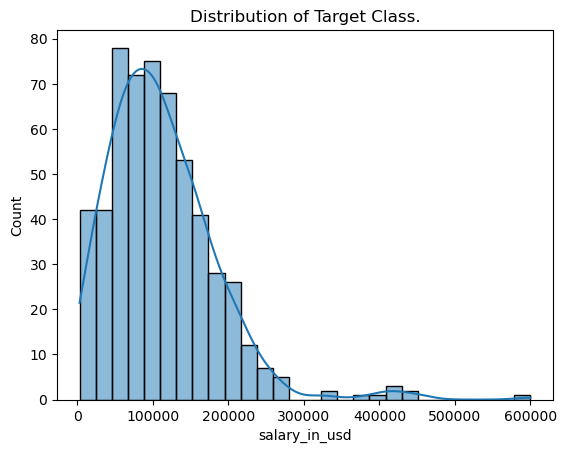

Skewness : 1.72


In [20]:
sns.histplot(df.salary_in_usd, kde=True)
plt.title("Distribution of Target Class.")
plt.show()
print(f"Skewness : {(df.salary_in_usd.skew()).round(2)}")

Here we can see that our target column is heavily right skewed, se we will take the log value for this column.

## 5. Data Cleaning and Preprocessing 

In [21]:
df.salary_in_usd = np.log1p(df['salary_in_usd'])
df.salary_in_usd.skew()

np.float64(-1.211192387171651)

In [22]:
X = df.drop(columns=['salary_in_usd'], axis=1)
y = df.salary_in_usd
X.shape, y.shape

((559, 6), (559,))

In [23]:
# le = LabelEncoder()
# X.job_title = le.fit_transform(X.job_title)
# X.head()

In [24]:
xtrain, xtest, ytrain, ytest = train_test_split(X,y, test_size=0.2, random_state=2)
xtrain.shape, ytest.shape

((447, 6), (112,))

In [25]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoding_cols = ['experience_level','employment_type','company_size','remote_ratio', 'work_year', 'job_title']
preprocessor = ColumnTransformer([
    ('OneHotEncoder',encoder, encoding_cols)
],remainder='passthrough')
xtrain = preprocessor.fit_transform(xtrain)
xtest = preprocessor.transform(xtest)

## 6. Training Models

In [26]:
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet':ElasticNet(),
    'RandomForestRegressor':RandomForestRegressor(),
    'Lasso':Lasso(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'XGBRegressor': XGBRegressor()
}

In [27]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    mae_test = mean_absolute_error(y_test,y_pred_test)
    mae_train = mean_absolute_error(y_train,y_pred_train)
    rmse_test = root_mean_squared_error(y_test,y_pred_test)
    rmse_train = root_mean_squared_error(y_train,y_pred_train)
    r2score_test = r2_score(y_test,y_pred_test)
    r2score_train = r2_score(y_train,y_pred_train)
    return mae_test,mae_train,rmse_test,rmse_train,r2score_test,r2score_train

In [28]:
res = []
for name,m in models.items():
    model = m
    model.fit(xtrain,ytrain)
    y_pred_test = model.predict(xtest)
    y_pred_train = model.predict(xtrain)
    mae_test,mae_train,rmse_test,rmse_train,r2score_test,r2score_train = check_score(y_pred_test,ytest,y_pred_train,ytrain)
    res.append({
            'Model':name,
            'MAE Test':mae_test,
            'MAE Train':mae_train,
            'RMSE Test':rmse_test,
            'RMSE Train':rmse_train,
            'R2 Score Test':r2score_test,
            'R2 Score Train':r2score_train
        })
    print(f"{name} Model Trained Sucessfully.")


LinearRegression Model Trained Sucessfully.
ElasticNet Model Trained Sucessfully.
RandomForestRegressor Model Trained Sucessfully.
Lasso Model Trained Sucessfully.
DecisionTreeRegressor Model Trained Sucessfully.
XGBRegressor Model Trained Sucessfully.


## 7. Comparing the Models based on Performance Metrices

In [29]:
res_df = pd.DataFrame(res).sort_values(by='R2 Score Test', ascending=False)
res_df

,Model,MAE Test,MAE Train,RMSE Test,RMSE Train,R2 Score Test,R2 Score Train
2,RandomForestRegressor,0.468738,0.272078,0.635481,0.369079,0.356581,0.782417
5,XGBRegressor,0.510655,0.253229,0.699193,0.369628,0.221097,0.781769
4,DecisionTreeRegressor,0.536760,0.176136,0.743281,0.310111,0.119773,0.846390
0,LinearRegression,0.547145,0.413692,0.743805,0.564473,0.118530,0.491054
1,ElasticNet,0.558781,0.594228,0.794284,0.791238,-0.005174,0.000000
3,Lasso,0.558781,0.594228,0.794284,0.791238,-0.005174,0.000000


<Axes: xlabel='Model'>

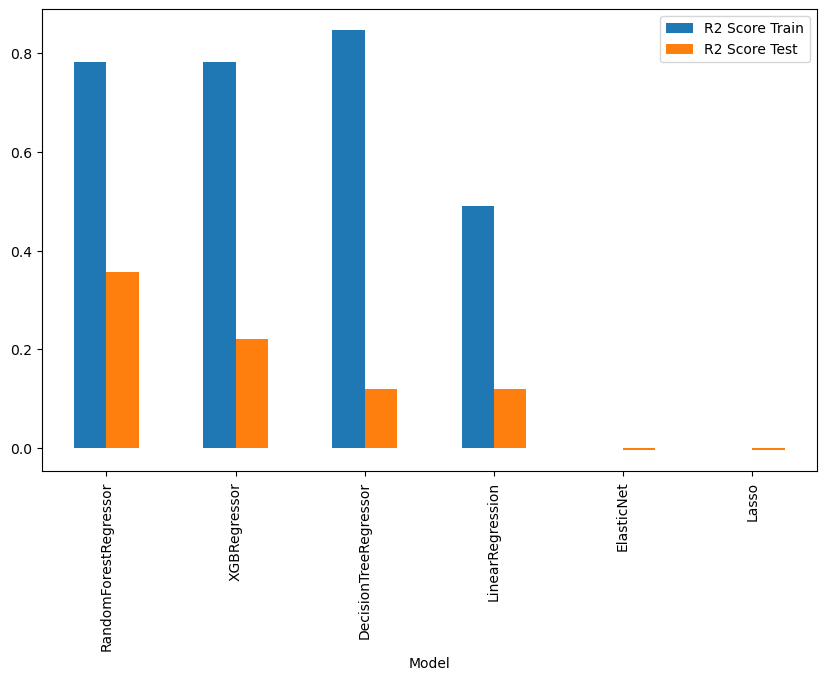

In [30]:
res_df.set_index(['Model'])[['R2 Score Train','R2 Score Test']].plot(kind='bar',figsize=(10,6))

## 8. Hyper-parameter Tuning

In [31]:
param = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}
tuner = GridSearchCV(RandomForestRegressor(), param_grid=param)
tuner.fit(xtrain,ytrain)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 4], 'min_samples_split': [5, 10], 'n_estimators': [100, 200]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [32]:
tuner.best_params_

{'max_depth': 5,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 100}

In [33]:
model = RandomForestRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=5, n_estimators=200)
model.fit(xtrain,ytrain)
ytestpred = model.predict(xtest)
ytrainpred = model.predict(xtrain)

In [34]:
print(f"Test Score after Tuning : {r2_score(ytest, ytestpred)}")
print(f"Train Score after Tuning : {r2_score(ytrain, ytrainpred)}")

Test Score after Tuning : 0.3336123586215649
Train Score after Tuning : 0.434113095485681


## 9. Testing on Unseen Data

In [35]:
xtrain = pd.DataFrame(xtrain, columns=preprocessor.get_feature_names_out())
unseen_data = xtrain.sample(5, random_state=30)
unseen_pred = np.expm1(model.predict(unseen_data)).round(2)
pd.DataFrame(unseen_pred,columns=[['Pridected Salary']])

,Pridected Salary
0,127742.26
1,46505.95
2,78588.10
3,77707.13
4,75532.18


## 10. Conclusion

- Trained and compared 6 models (LinearRegression,ElasticNet,RandomForestRegressor,Lasso,DecisionTreeRegressor,XGBRegressor) with hyperparameter tuning.
- The best-performing model was selected based on R2 Score.
- The selected model was used to predict on unseen samples successfully.